# Monoculture Treated - Mechanical Automatic Modeling
Decode processed data, fit treated model zoo, and run sensitivity/uncertainty analysis.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

  Activating project at `c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package`
Precompiling packages...
              ✗ MechanicalAutomaticModeling
  0 dependencies successfully precompiled in 32 seconds. 490 already precompiled.

The following 1 direct dependency failed to precompile:

MechanicalAutomaticModeling 

Failed to precompile MechanicalAutomaticModeling [4c59f1b9-0350-4485-8fe5-0c8559674061] to "C:\\Users\\elbak\\.julia\\compiled\\v1.12\\MechanicalAutomaticModeling\\jl_D155.tmp".
ERROR: LoadError: ArgumentError: Package MechanicalAutomaticModeling does not have BlackBoxOptim in its dependencies:
- Note that the following manifests in the load path were resolved with a different
  julia version, which may be the cause of the error. Try to re-resolve them in the
  current version, or consider deleting them if that fails:
    C:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\Manifest.toml (

In [2]:
using CSV, DataFrames, Plots, Dates, Statistics, DifferentialEquations
include(joinpath(@__DIR__, "..", "src", "MechanicalAutomaticModeling.jl"))
using .MechanicalAutomaticModeling
using GrowthParameterEstimation

In [3]:
condition = "monoculture_treated"
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)

decoded = MechanicalAutomaticModeling.IOUtils.decode_condition_dataframe(condition; start=@__DIR__)
name_set = Set(Symbol.(names(decoded)))

# Normalize metadata labels for consistent grouping and output tags.
if :cell_line in name_set
    decoded.cell_line = string.(decoded.cell_line)
end
if :density in name_set
    decoded.density = string.(decoded.density)
end
if :dose in name_set
    decoded.dose = Float64.(decoded.dose)
end
sort!(decoded, [:source_file, :replicate, :time])

decoded_path = joinpath(out.csv, "$(condition)_automatic_decoded.csv")
CSV.write(decoded_path, decoded)

function choose_group_cols(df::DataFrame)
    cols = Symbol[]
    name_set = Set(Symbol.(names(df)))
    for c in (:cell_line, :density, :dose)
        if c in name_set && length(unique(df[!, c])) > 1
            push!(cols, c)
        end
    end
    if isempty(cols) && (:source_file in name_set)
        push!(cols, :source_file)
    end
    return cols
end

group_cols = choose_group_cols(decoded)
coverage = isempty(group_cols) ?
    DataFrame(group = ["pooled"], n_rows = [nrow(decoded)], n_replicates = [length(unique(decoded.replicate))]) :
    combine(groupby(decoded, group_cols), nrow => :n_rows, :replicate => (x -> length(unique(x))) => :n_replicates)

coverage_path = joinpath(out.metrics, "$(condition)_decoded_group_coverage.csv")
CSV.write(coverage_path, coverage)

MechanicalAutomaticModeling.IOUtils.write_manifest_row(
    condition = condition,
    step = "decode",
    outputs = [decoded_path, coverage_path],
    start = @__DIR__,
)

Text(repr(first(decoded, min(12, nrow(decoded)))))

12×9 DataFrame
 Row │ time     count    source_file                     condition            density  cell_line   dose     mix      replicate
     │ Float64  Float64  String                          String               String   String      Float64  String3  Int64
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     1.0  332.641  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     0.67  A4               1
   2 │     1.0  178.076  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     1.0   A1               1
   3 │     1.0  328.856  A2780Naive_sample_averages.csv  monoculture_treated  20k      A2780Naive     1.47  C1               1
   4 │     1.0  563.739  A2780Naive_sample_averages.csv  monoculture_treated  30k      A2780Naive     0.67  B4               1
   5 │     1.0  332.851  A2780Naive_sample_averages.csv  monoculture_treated  30k      A2780Naive  

## API And Untreated Baseline Check
This notebook now inspects the installed GrowthParameterEstimation package API and loads the untreated best-fit baseline explicitly before any treated fitting step.

In [4]:
gpe_module_path = pathof(GrowthParameterEstimation)
gpe_source_dir = dirname(gpe_module_path)
gpe_source_files = filter(isfile, [
    gpe_module_path,
    joinpath(gpe_source_dir, "fitting.jl"),
    joinpath(gpe_source_dir, "analysis.jl"),
])
gpe_source_text = join(read.(gpe_source_files, String), "\n")

pipeline_api_summary = DataFrame(
    check = [
        "package_path",
        "has_default_config_symbol",
        "has_run_pipeline_symbol",
        "source_mentions_default_config",
        "source_mentions_run_pipeline",
    ],
    value = [
        string(gpe_module_path),
        string(isdefined(GrowthParameterEstimation, :default_config)),
        string(isdefined(GrowthParameterEstimation, :run_pipeline)),
        string(occursin("default_config", gpe_source_text)),
        string(occursin("run_pipeline", gpe_source_text)),
    ],
)

untreated_baseline = MechanicalAutomaticModeling.FitWorkflows.load_untreated_baseline(; start=@__DIR__)
untreated_baseline_summary = untreated_baseline === nothing ? DataFrame(
    key = ["status"],
    value = ["missing untreated baseline outputs"],
) : DataFrame(
    key = vcat(["model"], ["param_$(i)" for i in eachindex(untreated_baseline.params)]),
    value = vcat([untreated_baseline.model], string.(untreated_baseline.params)),
)

display(pipeline_api_summary)
untreated_baseline_summary

Row,check,value
,String,String
1,package_path,C:\\Users\\elbak\\.julia\\packages\\GrowthParameterEstimation\\NB9Qj\\src\\GrowthParameterEstimation.jl
2,has_default_config_symbol,true
3,has_run_pipeline_symbol,true
4,source_mentions_default_config,true
5,source_mentions_run_pipeline,true


Row,key,value
,String,String
1,model,logistic_growth
2,param_1,0.7715262470516224
3,param_2,4069.966384962819


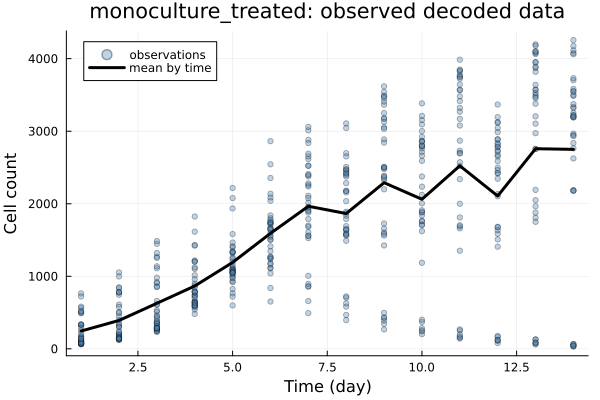

In [5]:
# Visualize decoded observations and their time-wise mean trend
obs_plot = scatter(
    decoded.time,
    decoded.count;
    alpha = 0.35,
    ms = 3,
    color = :steelblue,
    label = "observations",
    xlabel = "Time (day)",
    ylabel = "Cell count",
    title = "$(condition): observed decoded data",
    legend = :topleft,
)
time_means = combine(groupby(decoded, :time), :count => mean => :mean_count)
plot!(obs_plot, time_means.time, time_means.mean_count; lw = 3, color = :black, label = "mean by time")
display(obs_plot)

In [6]:
required_treated_models = [
    "hill_death_instantaneous",
    "one_stage_transit_linear_kill",
    "transit_hill_combined",
    "adaptive_ic50_hill",
    "population_balance_sr",
    "theta_hill_kill",
    "anchored_linear_kill",
    "anchored_hill_kill",
]

fit_artifacts = MechanicalAutomaticModeling.FitWorkflows.run_condition_fit!(
    decoded,
    condition;
    start = @__DIR__,
    untreated_baseline = untreated_baseline,
)

tested_models = sort(unique(String.(fit_artifacts.ranking.model)))
missing_models = setdiff(required_treated_models, tested_models)

println("Tested treated models: " * join(tested_models, ", "))
println("Missing required models: " * (isempty(missing_models) ? "none" : join(missing_models, ", ")))

Text(repr(first(fit_artifacts.ranking, min(12, nrow(fit_artifacts.ranking)))))

  Fitting hill_death_instantaneous at dose=0.67, cell=A2780Naive, density=20k...
  Fitting one_stage_transit_linear_kill at dose=0.67, cell=A2780Naive, density=20k...
  Fitting transit_hill_combined at dose=0.67, cell=A2780Naive, density=20k...
  Fitting adaptive_ic50_hill at dose=0.67, cell=A2780Naive, density=20k...
  Fitting population_balance_sr at dose=0.67, cell=A2780Naive, density=20k...
  Fitting theta_hill_kill at dose=0.67, cell=A2780Naive, density=20k...
  Fitting hill_death_instantaneous at dose=1.0, cell=A2780Naive, density=20k...
  Fitting one_stage_transit_linear_kill at dose=1.0, cell=A2780Naive, density=20k...
  Fitting transit_hill_combined at dose=1.0, cell=A2780Naive, density=20k...
  Fitting adaptive_ic50_hill at dose=1.0, cell=A2780Naive, density=20k...
  Fitting population_balance_sr at dose=1.0, cell=A2780Naive, density=20k...
  Fitting theta_hill_kill at dose=1.0, cell=A2780Naive, density=20k...
  Fitting hill_death_instantaneous at dose=1.47, cell=A2780Naive, 

12×7 DataFrame
 Row │ model                          dose     bic      ssr             params                             cell_line   density
     │ String                         Float64  Float64  Float64         String                             String      String
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ one_stage_transit_linear_kill     0.67  135.189       1.0289e5   (fit = [1.1763019811728295, 9.99…  A2780Naive  20k
   2 │ one_stage_transit_linear_kill     0.67  138.094  126614.0        (fit = [1.060654826036138, 9.999…  A2780Naive  30k
   3 │ one_stage_transit_linear_kill     1.47  139.81        1.43124e5  (fit = [0.6460626951257646, 2058…  A2780Naive  20k
   4 │ transit_hill_combined             1.47  145.088       1.43124e5  (fit = [0.6460609190250016, 2058…  A2780Naive  20k
   5 │ theta_hill_kill                   1.47  146.08        1.53633e5  (fit = [2.076566734507677, 4286.…  A2780

## Staged Treated Dose Diagnostics
This section uses the untreated best-fit growth parameters as the treated baseline, assumes `ec50 = 1.0`, and then reports pooled dose-aware residual diagnostics so failed treated fits are obvious.

In [7]:
staged_dose_means = combine(
    groupby(sort(decoded, [:dose, :time]), [:dose, :time]),
    :count => mean => :mean_count,
    nrow => :n_obs,
    )

function solve_staged_hill_series(dose, times, y0, baseline_params, emax, hill_n; ec50=1.0)
    r, K = baseline_params
    function staged_hill_model!(du, u, p, t)
        N = max(u[1], 0.0)
        kill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
        growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
        du[1] = growth - kill * N
    end
    prob = ODEProblem(staged_hill_model!, [Float64(y0)], (Float64(times[1]), Float64(times[end])), Float64[])
    sol = solve(prob, Tsit5(); reltol=1e-8, abstol=1e-8, saveat=Float64.(times))
    return [u[1] for u in sol.u]
end

dose_groups = groupby(staged_dose_means, :dose)
staged_ec50 = 1.0
staged_fit_summary = DataFrame()
dose_residual_summary = DataFrame()
staged_overlay = DataFrame()

if untreated_baseline === nothing || length(untreated_baseline.params) < 2
    staged_fit_summary = DataFrame(metric=["status"], value=["untreated baseline unavailable; staged diagnostics skipped"])
    dose_residual_summary = DataFrame(status=["untreated baseline unavailable; staged diagnostics skipped"])
else
    emax_grid = collect(range(0.05, 2.0, length=25))
    hill_grid = collect(range(0.5, 4.0, length=15))
    best_stage = (emax=NaN, hill_n=NaN, sse=Inf)

    for emax in emax_grid, hill_n in hill_grid
        total_sse = 0.0
        failed = false
        for grp in dose_groups
            times = Float64.(grp.time)
            observed = Float64.(grp.mean_count)
            predicted = solve_staged_hill_series(Float64(first(grp.dose)), times, observed[1], untreated_baseline.params, emax, hill_n; ec50=staged_ec50)
            if length(predicted) != length(observed) || any(v -> !isfinite(v), predicted)
                failed = true
                break
            end
            total_sse += sum((observed .- predicted) .^ 2)
        end
        if !failed && total_sse < best_stage.sse
            best_stage = (emax=emax, hill_n=hill_n, sse=total_sse)
        end
    end

    overlay_rows = NamedTuple[]
    residual_rows = NamedTuple[]
    for grp in dose_groups
        dose = Float64(first(grp.dose))
        times = Float64.(grp.time)
        observed = Float64.(grp.mean_count)
        predicted = solve_staged_hill_series(dose, times, observed[1], untreated_baseline.params, best_stage.emax, best_stage.hill_n; ec50=staged_ec50)
        residual = observed .- predicted
        for i in eachindex(times)
            push!(overlay_rows, (dose=dose, time=times[i], observed=observed[i], predicted=predicted[i], residual=residual[i]))
        end
        push!(residual_rows, (
            dose=dose,
            n_points=length(times),
            rmse=sqrt(mean(residual .^ 2)),
            mae=mean(abs.(residual)),
            sse=sum(residual .^ 2),
            initial_count=observed[1],
            final_observed=observed[end],
            final_predicted=predicted[end],
        ))
    end

    staged_overlay = sort(DataFrame(overlay_rows), [:dose, :time])
    dose_residual_summary = sort(DataFrame(residual_rows), :dose)
    staged_fit_summary = DataFrame(
        metric = ["untreated_model", "untreated_r", "untreated_K", "assumed_ec50", "best_emax", "best_hill_n", "pooled_sse"],
        value = [
            untreated_baseline.model,
            string(untreated_baseline.params[1]),
            string(untreated_baseline.params[2]),
            string(staged_ec50),
            string(best_stage.emax),
            string(best_stage.hill_n),
            string(best_stage.sse),
        ],
    )

    staged_dir = joinpath(out.csv, "staged_diagnostics")
    mkpath(staged_dir)
    CSV.write(joinpath(staged_dir, "staged_hill_fit_summary.csv"), staged_fit_summary)
    CSV.write(joinpath(staged_dir, "staged_hill_residual_summary_by_dose.csv"), dose_residual_summary)
    CSV.write(joinpath(staged_dir, "staged_hill_overlay_by_dose.csv"), staged_overlay)
end

display(staged_fit_summary)
dose_residual_summary

Row,metric,value
,String,String
1,untreated_model,logistic_growth
2,untreated_r,0.7715262470516224
3,untreated_K,4069.966384962819
4,assumed_ec50,1.0
5,best_emax,0.5375
6,best_hill_n,0.5
7,pooled_sse,2.0981406287349265e7


Row,dose,n_points,rmse,mae,sse,initial_count,final_observed,final_predicted
,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64
1,0.67,14,950.941,783.465,1.266e7,323.359,1675.68,2772.05
2,1.0,14,329.753,270.104,1.52232e6,160.558,3273.95,2593.88
3,1.47,14,696.883,563.601,6.79905e6,252.912,3299.21,2471.27


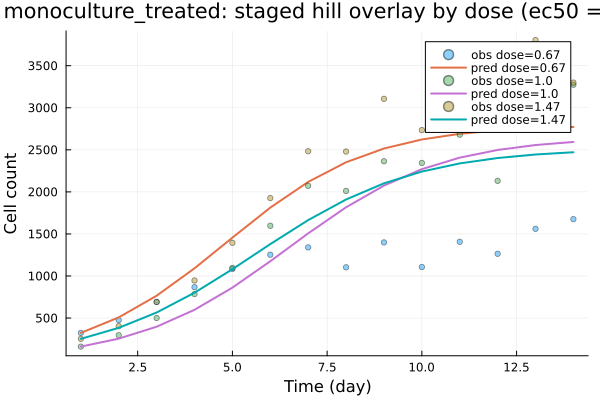

In [8]:
staged_overlay_plot = plot(
    xlabel = "Time (day)",
    ylabel = "Cell count",
    title = "$(condition): staged hill overlay by dose (ec50 = 1.0)",
    legend = :topright,
    )

if nrow(staged_overlay) == 0
    println("No staged overlay data available.")
else
    for dose in sort(unique(staged_overlay.dose))
        dose_df = sort(staged_overlay[staged_overlay.dose .== dose, :], :time)
        scatter!(staged_overlay_plot, dose_df.time, dose_df.observed; ms=3, alpha=0.45, label="obs dose=$(dose)")
        plot!(staged_overlay_plot, dose_df.time, dose_df.predicted; lw=2, label="pred dose=$(dose)")
    end
    display(staged_overlay_plot)
end

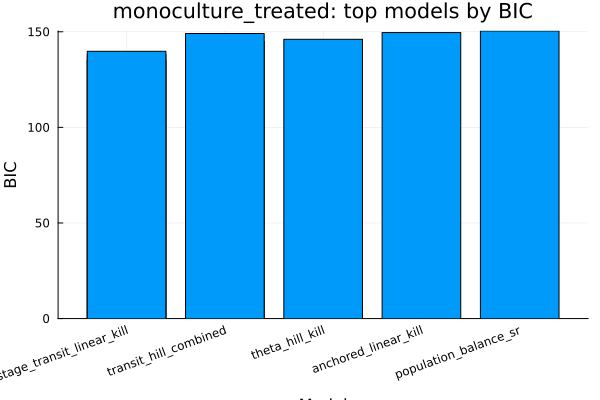

Overlay CSV is missing required columns: time, observed


In [9]:
# Visualize model quality (BIC) and model-vs-data overlay, when available
ranking_sorted = sort(fit_artifacts.ranking, :bic)
top_n = min(8, nrow(ranking_sorted))
bic_plot = bar(
    string.(ranking_sorted.model[1:top_n]),
    ranking_sorted.bic[1:top_n];
    legend = false,
    xlabel = "Model",
    ylabel = "BIC",
    title = "$(condition): top models by BIC",
    xrotation = 20,
)
display(bic_plot)

overlay_dir = joinpath(out.csv, "figures")
overlay_csvs = isdir(overlay_dir) ? sort(filter(f -> endswith(lowercase(f), "_overlay.csv"), readdir(overlay_dir; join = true))) : String[]

if isempty(overlay_csvs)
    println("No overlay CSV found in $(overlay_dir).")
else
    overlay = CSV.read(first(overlay_csvs), DataFrame)
    if !(:time in names(overlay) && :observed in names(overlay))
        println("Overlay CSV is missing required columns: time, observed")
    else
        p = scatter(
            overlay.time,
            overlay.observed;
            alpha = 0.4,
            ms = 3,
            color = :black,
            label = "observed",
            xlabel = "Time (day)",
            ylabel = "Cell count",
            title = "$(condition): model overlays",
        )

        pred_cols = filter(c -> startswith(String(c), "pred_"), names(overlay))
        plotted = 0
        for c in pred_cols
            mask = [!(ismissing(v) || (v isa AbstractFloat && isnan(v))) for v in overlay[!, c]]
            if any(mask)
                plot!(p, overlay.time[mask], overlay[mask, c]; lw = 2, label = replace(String(c), "pred_" => ""))
                plotted += 1
            end
        end

        if plotted == 0
            println("No non-missing model predictions found in overlay CSV.")
        end

        display(p)
    end
end

In [10]:
analysis_artifacts = MechanicalAutomaticModeling.AnalysisWorkflows.run_condition_analysis!(decoded, fit_artifacts, condition; start=@__DIR__)
Text(repr(analysis_artifacts.sensitivity))

1×2 DataFrame
 Row │ model                          note
     │ String                         String
─────┼──────────────────────────────────────────────────────────────────
   1 │ one_stage_transit_linear_kill  Sensitivity call not available w…

In [11]:
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
summary = DataFrame(
    condition = [condition],
    decoded_rows = [nrow(decoded)],
    fit_rows = [nrow(fit_artifacts.ranking)],
    sensitivity_rows = [nrow(analysis_artifacts.sensitivity)],
    generated_at = [Dates.format(now(UTC), dateformat"yyyy-mm-ddTHH:MM:SS")]
)
summary_path = joinpath(out.metrics, "$(condition)_automatic_summary.csv")
CSV.write(summary_path, summary)
MechanicalAutomaticModeling.IOUtils.write_manifest_row(condition=condition, step="summary", outputs=[summary_path], start=@__DIR__)
Text(repr(summary))

1×5 DataFrame
 Row │ condition            decoded_rows  fit_rows  sensitivity_rows  generated_at
     │ String               Int64         Int64     Int64             String
─────┼────────────────────────────────────────────────────────────────────────────────────
   1 │ monoculture_treated           504        96                 1  2026-04-28T05:10:00

## Final Plot: Best Fitted Model Over Data
This final cell overlays the best-BIC fitted model trajectory on top of the observed data and saves the figure to the condition image output folder.

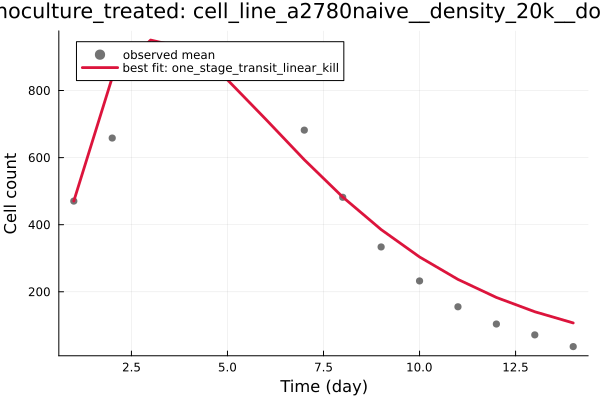

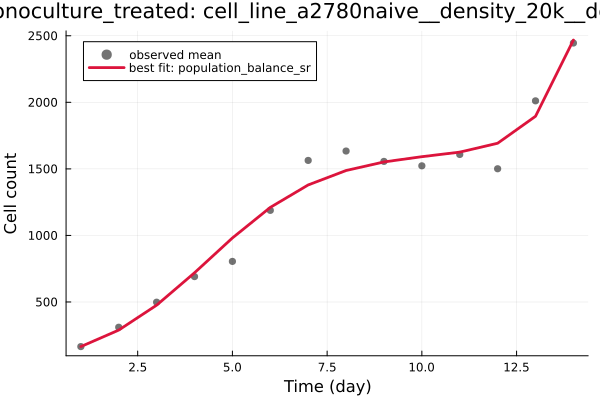

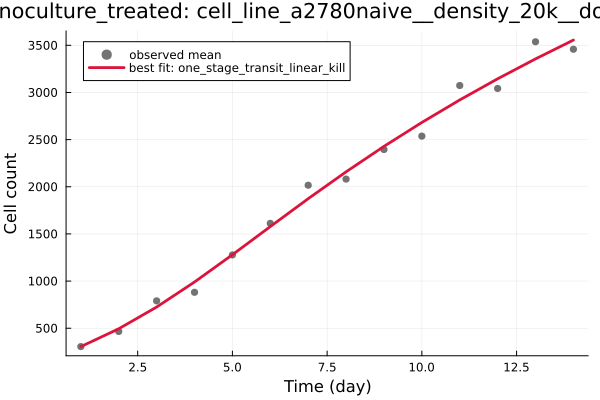

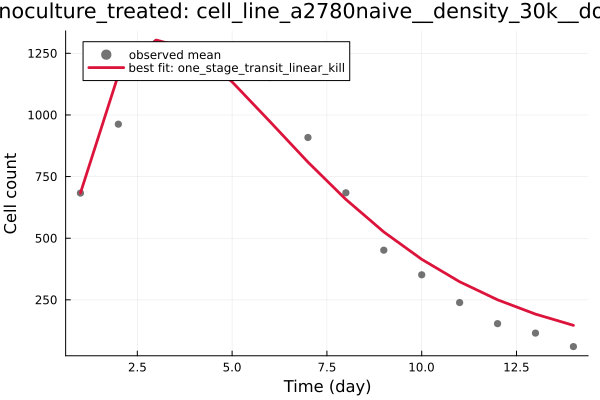

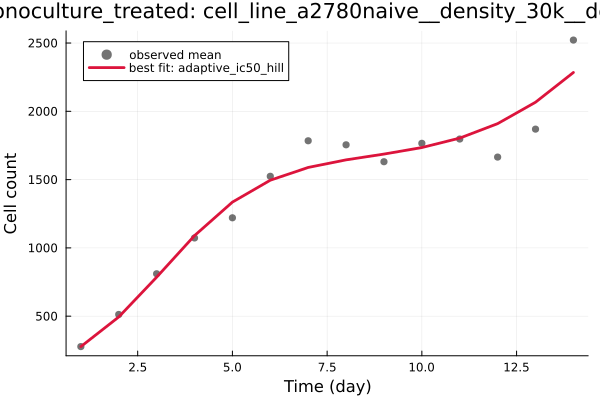

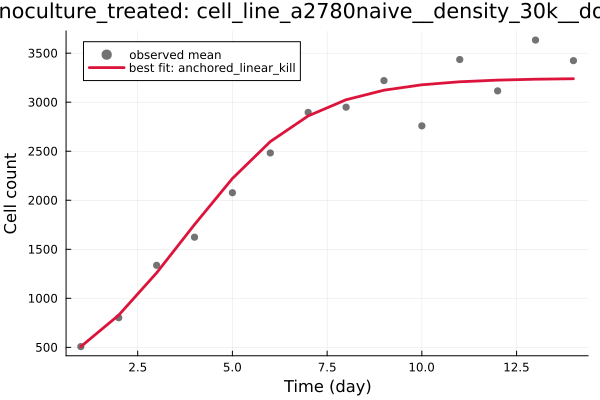

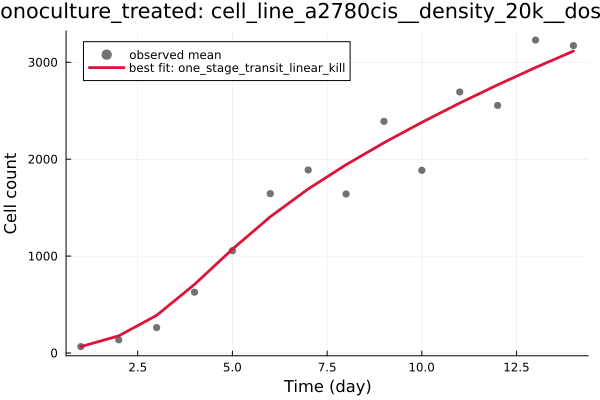

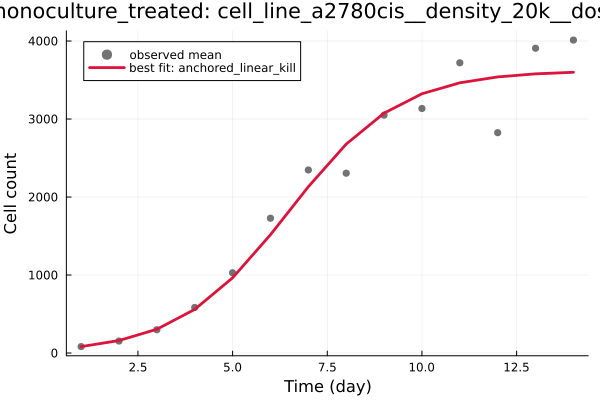

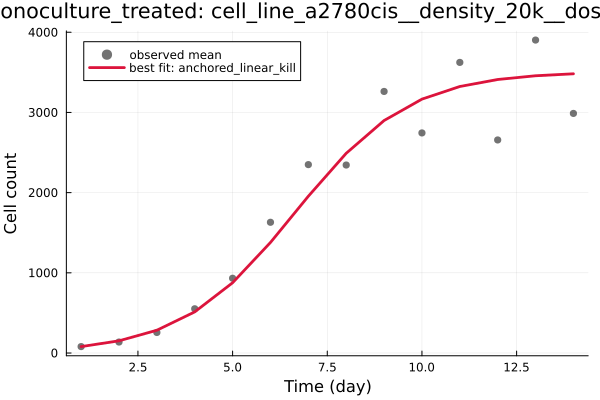

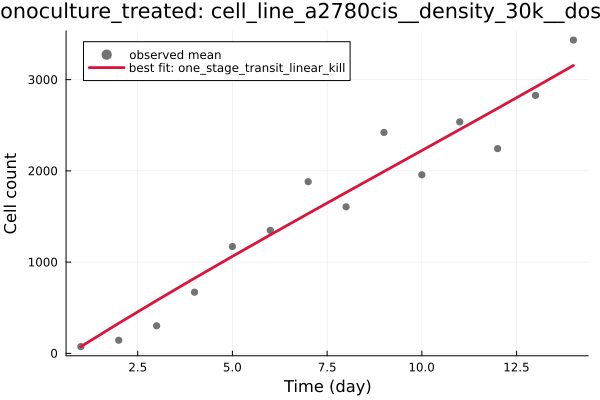

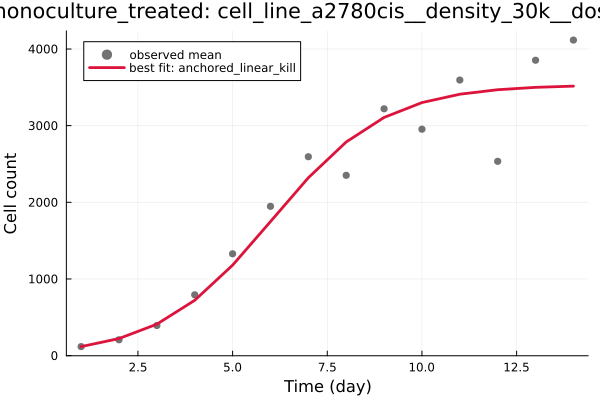

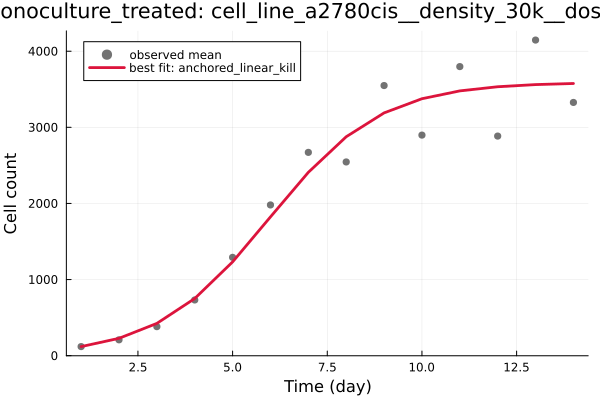

Exported group overlays: 25 files
Overlay image dir: c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\outputs\images\monoculture_treated\figures
Overlay csv dir: c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\outputs\csv\monoculture_treated\figures


In [12]:
# Final overlays: best fitted treated model against observations for all treated groups
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
overlay_img_dir = joinpath(out.images, "figures")
overlay_csv_dir = joinpath(out.csv, "figures")
mkpath(overlay_img_dir)
mkpath(overlay_csv_dir)

sanitize_tag(s) = replace(lowercase(string(s)), r"[^a-z0-9]+" => "_")

function extract_named_param(params_txt::String, key::String)
    m = match(Regex(key * raw"\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)"), params_txt)
    return m === nothing ? nothing : parse(Float64, m.captures[1])
end

function parse_fit_vector(params_txt::String)
    m = match(r"fit\s*=\s*\[([^\]]+)\]", params_txt)
    if m === nothing
        return Float64[]
    end
    nums = [parse(Float64, mm.match) for mm in eachmatch(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", m.captures[1])]
    return nums
end

function solve_treated_prediction(model_name::String, params_txt::String, t::Vector{Float64}, n0::Float64, dose::Float64)
    fit_params = parse_fit_vector(params_txt)
    r_anchor = extract_named_param(params_txt, "r_anchor")
    K_anchor = extract_named_param(params_txt, "K_anchor")

    function safe_solve(ode!, u0, p)
        prob = ODEProblem(ode!, u0, (first(t), last(t)), p)
        sol = solve(prob, Tsit5(); reltol=1e-8, abstol=1e-8, saveat=t)
        return sol.retcode == ReturnCode.Success ? sol : nothing
    end

    if model_name == "hill_death_instantaneous" && length(fit_params) >= 5
        r, K, emax, ec50, hill_n = fit_params[1:5]
        ode! = function (du, u, p, tt)
            N = max(u[1], 0.0)
            kill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
            growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
            du[1] = growth - kill * N
        end
        sol = safe_solve(ode!, [max(n0, 1.0)], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] for u in sol.u]
    elseif model_name == "one_stage_transit_linear_kill" && length(fit_params) >= 4
        r, K, k_kill, tau = fit_params[1:4]
        ode! = function (du, u, p, tt)
            N1 = max(u[1], 0.0)
            N2 = max(u[2], 0.0)
            growth = r * N1 * max(0.0, 1 - N1 / max(K, 1e-8))
            damage_flux = k_kill * dose * N1
            clearance_flux = (1 / max(tau, 1e-8)) * N2
            du[1] = growth - damage_flux
            du[2] = damage_flux - clearance_flux
        end
        sol = safe_solve(ode!, [max(n0, 1.0), 0.0], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] + u[2] for u in sol.u]
    elseif model_name == "transit_hill_combined" && length(fit_params) >= 6
        r, K, emax, ec50, hill_n, tau = fit_params[1:6]
        ode! = function (du, u, p, tt)
            N1 = max(u[1], 0.0)
            N2 = max(u[2], 0.0)
            k_hill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
            growth = r * N1 * max(0.0, 1 - N1 / max(K, 1e-8))
            damage_flux = k_hill * N1
            clearance_flux = (1 / max(tau, 1e-8)) * N2
            du[1] = growth - damage_flux
            du[2] = damage_flux - clearance_flux
        end
        sol = safe_solve(ode!, [max(n0, 1.0), 0.0], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] + u[2] for u in sol.u]
    elseif model_name == "adaptive_ic50_hill" && length(fit_params) >= 7
        r, K, emax, ic50_0, hill_n, adapt_rate, relax_rate = fit_params[1:7]
        ode! = function (du, u, p, tt)
            N = max(u[1], 0.0)
            A = max(u[2], 0.0)
            ic50_eff = ic50_0 * (1 + A)
            kill = emax * (dose^hill_n / (ic50_eff^hill_n + dose^hill_n + 1e-12))
            growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
            du[1] = growth - kill * N
            du[2] = adapt_rate * dose - relax_rate * A
        end
        sol = safe_solve(ode!, [max(n0, 1.0), 0.0], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] for u in sol.u]
    elseif model_name == "population_balance_sr" && length(fit_params) >= 8
        r, K, emax_s, emax_r, ec50, hill_n, k_sr, k_rs = fit_params[1:8]
        ode! = function (du, u, p, tt)
            S = max(u[1], 0.0)
            R = max(u[2], 0.0)
            N = S + R
            hill = dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12)
            kill_s = emax_s * hill
            kill_r = emax_r * hill
            growth_common = max(0.0, 1 - N / max(K, 1e-8))
            dS_growth = r * S * growth_common
            dR_growth = r * R * growth_common
            du[1] = dS_growth - kill_s * S - k_sr * dose * S + k_rs * R
            du[2] = dR_growth - kill_r * R + k_sr * dose * S - k_rs * R
        end
        sol = safe_solve(ode!, [max(n0, 1.0), 0.0], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] + u[2] for u in sol.u]
    elseif model_name == "theta_hill_kill" && length(fit_params) >= 6
        r, K, theta, emax, ec50, hill_n = fit_params[1:6]
        ode! = function (du, u, p, tt)
            N = max(u[1], 0.0)
            crowding = max(0.0, 1 - (N / max(K, 1e-8))^max(theta, 1e-8))
            kill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
            du[1] = r * N * crowding - kill * N
        end
        sol = safe_solve(ode!, [max(n0, 1.0)], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] for u in sol.u]
    elseif model_name == "anchored_linear_kill"
        k_kill = extract_named_param(params_txt, "k_kill")
        r = r_anchor === nothing ? 0.3 : r_anchor
        K = K_anchor === nothing ? max(n0, 100.0) : K_anchor
        if k_kill === nothing
            return fill(NaN, length(t))
        end
        ode! = function (du, u, p, tt)
            N = max(u[1], 0.0)
            growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
            du[1] = growth - k_kill * dose * N
        end
        sol = safe_solve(ode!, [max(n0, 1.0)], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] for u in sol.u]
    elseif model_name == "anchored_hill_kill"
        emax = extract_named_param(params_txt, "emax")
        ec50 = extract_named_param(params_txt, "ec50")
        hill_n = extract_named_param(params_txt, "hill_n")
        r = r_anchor === nothing ? 0.3 : r_anchor
        K = K_anchor === nothing ? max(n0, 100.0) : K_anchor
        if emax === nothing || ec50 === nothing || hill_n === nothing
            return fill(NaN, length(t))
        end
        ode! = function (du, u, p, tt)
            N = max(u[1], 0.0)
            kill = emax * (dose^hill_n / (ec50^hill_n + dose^hill_n + 1e-12))
            growth = r * N * max(0.0, 1 - N / max(K, 1e-8))
            du[1] = growth - kill * N
        end
        sol = safe_solve(ode!, [max(n0, 1.0)], Float64[])
        return sol === nothing ? fill(NaN, length(t)) : [u[1] for u in sol.u]
    end

    return fill(NaN, length(t))
end

function choose_group_cols(df::DataFrame)
    cols = Symbol[]
    name_set = Set(Symbol.(names(df)))
    for c in (:cell_line, :density, :dose)
        if c in name_set && length(unique(df[!, c])) > 1
            push!(cols, c)
        end
    end
    if isempty(cols) && (:source_file in name_set)
        push!(cols, :source_file)
    end
    return cols
end

group_cols = choose_group_cols(decoded)
all_overlay_frames = DataFrame[]
saved_paths = String[]

for grp in groupby(decoded, group_cols)
    key_map = Dict{Symbol,Any}(c => first(grp[!, c]) for c in group_cols)

    group_rank = fit_artifacts.ranking
    for c in (:cell_line, :density, :dose)
        if (c in Symbol.(names(group_rank))) && (c in keys(key_map))
            group_rank = filter(r -> string(r[c]) == string(key_map[c]), group_rank)
        end
    end
    nrow(group_rank) == 0 && continue

    best_row = first(sort(group_rank, :bic), 1)
    best_model = String(best_row.model[1])
    params_txt = String(best_row.params[1])

    obs_mean = combine(groupby(grp, :time), :count => mean => :observed)
    sort!(obs_mean, :time)

    dose_val = :dose in keys(key_map) ? Float64(key_map[:dose]) : 0.0
    n0 = max(first(obs_mean.observed), 1e-8)
    pred = solve_treated_prediction(best_model, params_txt, Float64.(obs_mean.time), n0, dose_val)

    tag = join(["$(c)_$(sanitize_tag(key_map[c]))" for c in group_cols], "__")

    overlay_df = DataFrame(
        time = obs_mean.time,
        observed = obs_mean.observed,
        prediction = pred,
        best_model = fill(best_model, nrow(obs_mean)),
    )
    for c in group_cols
        overlay_df[!, c] = fill(string(key_map[c]), nrow(obs_mean))
    end

    overlay_csv_path = joinpath(overlay_csv_dir, "$(condition)_$(tag)_best_overlay.csv")
    CSV.write(overlay_csv_path, overlay_df)
    push!(saved_paths, overlay_csv_path)
    push!(all_overlay_frames, overlay_df)

    p = scatter(
        obs_mean.time,
        obs_mean.observed;
        alpha = 0.55,
        ms = 4,
        color = :black,
        label = "observed mean",
        xlabel = "Time (day)",
        ylabel = "Cell count",
        title = "$(condition): $(tag)",
        legend = :topleft,
    )
    finite_mask = .!isnan.(pred)
    if any(finite_mask)
        plot!(p, obs_mean.time[finite_mask], pred[finite_mask]; lw = 2.8, color = :crimson, label = "best fit: $(best_model)")
    else
        annotate!(p, minimum(obs_mean.time), maximum(obs_mean.observed), text("prediction unavailable for $(best_model)", 8, :red))
    end

    overlay_img_path = joinpath(overlay_img_dir, "$(condition)_$(tag)_best_overlay.png")
    savefig(p, overlay_img_path)
    push!(saved_paths, overlay_img_path)
    display(p)
end

if !isempty(all_overlay_frames)
    all_overlay_df = vcat(all_overlay_frames...)
    all_overlay_path = joinpath(overlay_csv_dir, "$(condition)_all_groups_best_overlays.csv")
    CSV.write(all_overlay_path, all_overlay_df)
    push!(saved_paths, all_overlay_path)
end

MechanicalAutomaticModeling.IOUtils.write_manifest_row(
    condition = condition,
    step = "all-group-best-overlays",
    outputs = saved_paths,
    start = @__DIR__,
)

println("Exported group overlays: $(length(saved_paths)) files")
println("Overlay image dir: $(overlay_img_dir)")
println("Overlay csv dir: $(overlay_csv_dir)")